<a href="https://colab.research.google.com/github/fatmasenguler/laplacian-minor-hierarchy/blob/main/AlphaFold3_5HED_25_SECONDS_ensemble_UPLOAD_FIRST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AlphaFold 3 (OpenFold3)

**FIXED setup:** validates the `alphafold3` import and stops immediately on failed inference.

Predict protein, RNA, DNA, and small-molecule structures using [AlphaFold 3](https://www.nature.com/articles/s41586-024-07487-w) with the freely available [OpenFold3](https://github.com/aqlaboratory/openfold) weights (Apache 2.0 — no commercial restrictions).

MSA generation via the [ColabFold](https://github.com/sokrypton/ColabFold) MMseqs2 server — **no local databases required**.

For this 5HED notebook, choose **Runtime → Run all** and the first executable cell will ask you to upload the exact **`5HED.pdb`**. Chain A and chain B sequences are extracted from that uploaded file and used to construct the AF3 input; they are not hard-coded.

**Citations:**
- Abramson et al. (2024) AlphaFold 3. *Nature* [doi:10.1038/s41586-024-07487-w](https://doi.org/10.1038/s41586-024-07487-w)
- Mirdita et al. (2022) ColabFold. *Nature Methods* [doi:10.1038/s41592-022-01488-1](https://doi.org/10.1038/s41592-022-01488-1)
- The OpenFold3 Team (2025) [Github](https://github.com/aqlaboratory/openfold-3) - [doi:10.5281/zenodo.19001000](https://doi.org/10.5281/zenodo.19001000)

**Credits:** AF3 code: Google DeepMind (Apache 2.0) · OF3 weights: AlQuraishi Lab (Apache 2.0)


In [1]:
#@title FIRST: Upload your 5HED.pdb
from google.colab import files
import os, hashlib

REQUIRED_PDB_NAME = '5HED.pdb'
INPUT_PDB_PATH = f'/content/{REQUIRED_PDB_NAME}'

print('Please choose the exact 5HED.pdb file that you want this notebook to use.')
uploaded = files.upload()

if len(uploaded) != 1:
    raise ValueError(f'Upload exactly one file named {REQUIRED_PDB_NAME}. Received: {list(uploaded)}')

uploaded_name, uploaded_bytes = next(iter(uploaded.items()))
if uploaded_name != REQUIRED_PDB_NAME:
    raise ValueError(
        f'Expected a file named exactly {REQUIRED_PDB_NAME}, but received {uploaded_name!r}. '
        f'Rename your file to {REQUIRED_PDB_NAME} and rerun this cell.'
    )

# Write the bytes selected in THIS upload prompt to the one canonical path used below.
with open(INPUT_PDB_PATH, 'wb') as f:
    f.write(uploaded_bytes)

PDB_SHA256 = hashlib.sha256(uploaded_bytes).hexdigest()
PDB_SIZE_BYTES = len(uploaded_bytes)

# Minimal sanity checks before any installation or AF3 work starts.
text_head = uploaded_bytes[:200000].decode('utf-8', errors='ignore')
if not any(line.startswith(('ATOM  ', 'HETATM')) for line in text_head.splitlines()):
    raise ValueError('The uploaded file does not look like a PDB coordinate file (no ATOM/HETATM records found).')

print('\nINPUT LOCKED')
print('  uploaded file :', uploaded_name)
print('  notebook path :', INPUT_PDB_PATH)
print('  size           :', f'{PDB_SIZE_BYTES:,} bytes')
print('  SHA-256        :', PDB_SHA256)
print('\nEvery later cell uses INPUT_PDB_PATH; no PDB is downloaded or substituted.')


Please choose the exact 5HED.pdb file that you want this notebook to use.


Saving 5HED.pdb to 5HED.pdb

INPUT LOCKED
  uploaded file : 5HED.pdb
  notebook path : /content/5HED.pdb
  size           : 322,704 bytes
  SHA-256        : 220e53ca1860cc715a2628e1acf76b8d0fc7e5e899a5fdcdad75a3bafc215b66

Every later cell uses INPUT_PDB_PATH; no PDB is downloaded or substituted.


In [2]:
#@title Install / repair AlphaFold 3 dependencies (robust)
%%time
import os, sys, time, glob, subprocess, importlib.util, pathlib, shutil

use_af3_weights = True #@param {type:"boolean"}
#@markdown - Uses the sokrypton AlphaFold3 fork used by this notebook.
#@markdown - This cell validates the actual `alphafold3` import before marking setup complete.
USE_NATIVE = use_af3_weights
NATIVE_DIR = 'af3_native_weights'
AF3_WEIGHTS_URL = 'https://storage.googleapis.com/alphafold3/af3.bin.zst'
SETUP_MARKER = 'ALPHAFOLD3_READY_V2'

print('Python:', sys.version)
if sys.version_info < (3, 12):
    raise RuntimeError(
        'The current sokrypton/alphafold3 package requires Python >= 3.12. '
        f'This runtime is Python {sys.version_info.major}.{sys.version_info.minor}. '
        'Use a Colab runtime with Python 3.12+ and rerun from the top.'
    )

def run_checked(args, **kwargs):
    """Run a command and STOP immediately if it fails."""
    print('+', ' '.join(map(str, args)))
    return subprocess.run(args, check=True, **kwargs)

def af3_import_ok():
    try:
        import alphafold3
        from alphafold3.common import folding_input
        return True, getattr(alphafold3, '__file__', '(namespace package)')
    except Exception as e:
        return False, repr(e)

ok, where = af3_import_ok()
need_setup = (not ok) or (not os.path.isfile(SETUP_MARKER))

if need_setup:
    # Remove the OLD marker: the previous notebook could create it even when pip failed.
    for old in ['ALPHAFOLD3_READY', SETUP_MARKER]:
        if os.path.exists(old):
            os.remove(old)

    print('Installing/repairing Python packages...')
    # Match the current sokrypton/alphafold3 pyproject requirements.
    run_checked([
        sys.executable, '-m', 'pip', 'install', '-q', '--upgrade',
        'absl-py>=2.3.1', 'etils[epath]', 'dm-haiku==0.0.16',
        'jax[cuda12]==0.10.2', 'rdkit==2025.9.4',
        'zstandard', 'awscli', 'tokamax==0.0.12',
        'py3Dmol', 'py2Dmol', 'biopython'
    ])

    # Fast path: prebuilt CPython-3.12 wheel.  If that URL ever changes,
    # fall back to building directly from the current GitHub source.
    wheel_url = ('https://github.com/sokrypton/alphafold3/releases/download/v3.1.4/'
                 'alphafold3_open-3.1.4-cp312-cp312-manylinux_2_27_x86_64.'
                 'manylinux_2_28_x86_64.whl')
    installed = False
    if sys.version_info[:2] == (3, 12):
        try:
            run_checked([sys.executable, '-m', 'pip', 'install', '-q', '--no-deps', wheel_url])
            installed = True
        except subprocess.CalledProcessError:
            print('Prebuilt wheel install failed; falling back to GitHub source build...')

    if not installed:
        run_checked([
            sys.executable, '-m', 'pip', 'install', '-q', '--no-deps',
            'git+https://github.com/sokrypton/alphafold3.git@main'
        ])

    importlib.invalidate_caches()
    ok, where = af3_import_ok()
    if not ok:
        raise RuntimeError('AlphaFold3 installation finished but import still fails: ' + where)
    print('alphafold3 import OK:', where)

    # Fetch wrapper scripts from the SAME fork.
    base = 'https://raw.githubusercontent.com/sokrypton/alphafold3/refs/heads/main'
    for script in ['run_alphafold', 'convert_of3_weights']:
        run_checked(['wget', '-q', '-O', f'{script}.py', f'{base}/{script}.py'])

    # Build AF3 chemical-component data. Do not create a success marker unless it succeeds.
    print('Building AF3 data files...')
    run_checked(['build_data'])

    pathlib.Path(SETUP_MARKER).write_text(
        f'python={sys.version}\nalphafold3={where}\n', encoding='utf-8')
else:
    print('Existing AF3 setup validated:', where)

# Patch tokamax so limited-shared-memory consumer/Ada cards use the safer XLA path.
try:
    import tokamax
    _gu = os.path.join(os.path.dirname(tokamax.__file__), '_src', 'gpu_utils.py')
    if os.path.isfile(_gu):
        _s = open(_gu).read()
        _old = 'return float(device.compute_capability) >= 8.0'
        _new = ('cc = float(device.compute_capability)\n'
                '  return cc == 8.0 or cc >= 9.0  # datacenter only')
        if _old in _s:
            open(_gu, 'w').write(_s.replace(_old, _new))
            print('Patched tokamax GPU selection.')
except Exception as _e:
    print(f'(tokamax patch skipped: {_e})')

# Weights. Reuse an already-complete file; otherwise download and VERIFY before proceeding.
if USE_NATIVE:
    os.makedirs(NATIVE_DIR, exist_ok=True)
    native_file = f'{NATIVE_DIR}/af3.bin.zst'
    native_ok = os.path.isfile(native_file) and os.path.getsize(native_file) > 1_000_000
    if not native_ok:
        print('Fetching AlphaFold 3 weights configured by this notebook...')
        tmp = native_file + '.part'
        if os.path.exists(tmp): os.remove(tmp)
        run_checked(['wget', '-q', '-O', tmp, AF3_WEIGHTS_URL])
        if os.path.getsize(tmp) <= 1_000_000:
            raise RuntimeError('AF3 weights download is incomplete.')
        os.replace(tmp, native_file)
    print('Native weight file OK:', native_file, f'({os.path.getsize(native_file)/1e9:.2f} GB)')
else:
    of3_ckpt = 'of3-p2-155k.pt'
    if not (os.path.isfile(of3_ckpt) and os.path.getsize(of3_ckpt) > 10_000_000):
        print('Downloading OpenFold3 weights...')
        run_checked(['aws', 's3', 'cp', 's3://openfold/staging/of3-p2-155k.pt', '.', '--no-sign-request'])
    converted = 'af3_converted_weights/of3_ported_weights.bin.zst'
    if not os.path.isfile(converted):
        run_checked([sys.executable, 'convert_of3_weights.py',
                     '--of3_checkpoint', of3_ckpt, '--output_dir', 'af3_converted_weights'])

ok, where = af3_import_ok()
assert ok, where
print('Setup complete. alphafold3 import verified.')


Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Installing/repairing Python packages...
+ /usr/bin/python3 -m pip install -q --upgrade absl-py>=2.3.1 etils[epath] dm-haiku==0.0.16 jax[cuda12]==0.10.2 rdkit==2025.9.4 zstandard awscli tokamax==0.0.12 py3Dmol py2Dmol biopython
+ /usr/bin/python3 -m pip install -q --no-deps git+https://github.com/sokrypton/alphafold3.git@main
alphafold3 import OK: /usr/local/lib/python3.13/dist-packages/alphafold3/__init__.py
+ wget -q -O run_alphafold.py https://raw.githubusercontent.com/sokrypton/alphafold3/refs/heads/main/run_alphafold.py
+ wget -q -O convert_of3_weights.py https://raw.githubusercontent.com/sokrypton/alphafold3/refs/heads/main/convert_of3_weights.py
Building AF3 data files...
+ build_data
Patched tokamax GPU selection.
Fetching AlphaFold 3 weights configured by this notebook...
+ wget -q -O af3_native_weights/af3.bin.zst.part https://storage.googleapis.com/alphafold3/af3.bin.zst
Native weight file OK: af3_native_weights/af3.b

In [3]:
#@title Input sequences — extracted ONLY from the uploaded 5HED.pdb
import re, os, json, hashlib

if 'INPUT_PDB_PATH' not in globals() or not os.path.isfile(INPUT_PDB_PATH):
    raise RuntimeError('Run the FIRST upload cell and upload 5HED.pdb before this cell.')

# Standard/commonly encountered amino-acid residue names.
AA3_TO_1 = {
    'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G',
    'HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S',
    'THR':'T','TRP':'W','TYR':'Y','VAL':'V',
    'MSE':'M','SEC':'U','PYL':'O','ASX':'B','GLX':'Z'
}

def pdb_chain_sequence(pdb_path, chain_id):
    """Extract one residue per (chain, resseq, insertion code) from ATOM records."""
    seq = []
    seen = set()
    unknown = []
    with open(pdb_path, 'r', errors='ignore') as f:
        for line in f:
            if not line.startswith('ATOM  '):
                continue
            if len(line) < 27 or line[21].strip() != chain_id:
                continue
            resname = line[17:20].strip().upper()
            resid = (line[22:26].strip(), line[26].strip())
            if resid in seen:
                continue
            seen.add(resid)
            aa = AA3_TO_1.get(resname)
            if aa is None:
                unknown.append((resid, resname))
            else:
                seq.append(aa)
    if unknown:
        raise ValueError(f'Unsupported residue name(s) in chain {chain_id}: {unknown[:10]}')
    if not seq:
        raise ValueError(f'No protein ATOM residues found for chain {chain_id} in {pdb_path}.')
    return ''.join(seq)

# 5HED: protein PDZ chain A + bound peptide chain B.
seq_A = pdb_chain_sequence(INPUT_PDB_PATH, 'A')
seq_B = pdb_chain_sequence(INPUT_PDB_PATH, 'B')
protein = f'{seq_A}:{seq_B}'

dna = ''
rna = ''
ligand_ccd = ''
ligand_smiles = ''

print('AF3 INPUT SOURCE:', INPUT_PDB_PATH)
print('PDB SHA-256    :', PDB_SHA256 if 'PDB_SHA256' in globals() else hashlib.sha256(open(INPUT_PDB_PATH,'rb').read()).hexdigest())
print(f'Chain A from uploaded PDB: {len(seq_A)} residues')
print(seq_A)
print(f'Chain B from uploaded PDB: {len(seq_B)} residues')
print(seq_B)

if len(seq_A) != 118 or len(seq_B) != 8:
    raise ValueError(
        f'This does not match the expected 5HED A/B lengths (118, 8); got ({len(seq_A)}, {len(seq_B)}). '
        'Check that you uploaded the intended 5HED.pdb.'
    )

#@markdown ### Run settings
#@markdown The AF3 sequences above are read directly from the uploaded **5HED.pdb**. Default is **5 seeds**; with 5 diffusion samples/seed this gives **25 structures**.
jobname = '5HED_25' #@param {type:"string"}
msa_mode = "mmseqs2_server" #@param ["mmseqs2_server", "single_sequence"]
seeds = '1,2,3,4,5' #@param {type:"string"}
on_existing = "skip" #@param ["skip", "overwrite"]
#@markdown - `msa_mode`: `single_sequence` skips the MSA (faster, lower accuracy).
#@markdown - `seeds`: comma-separated, e.g. `1,2,3`.
#@markdown - `on_existing`: `skip` keeps an already completed run with the same PDB-derived sequences and seeds.

# Split a box into entries: collapse colon runs, drop whitespace, skip empties
def split_entries(s):
  s = re.sub(r':+', ':', s).strip(':')
  return [e for e in (''.join(tok.split()) for tok in s.split(':')) if e]

prot_seqs   = [e.upper() for e in split_entries(protein)]
dna_seqs    = [e.upper() for e in split_entries(dna)]
rna_seqs    = [e.upper() for e in split_entries(rna)]
ccd_codes   = [e.upper() for e in split_entries(ligand_ccd)]
smiles_strs = split_entries(ligand_smiles)

# Build AF3 chain entities (IDs A, B, C, ... in canonical order)
CHAIN_IDS = list('ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz')
chains, prot_groups, idx = [], {}, 0

for seq in prot_seqs:
  cid = CHAIN_IDS[idx]; idx += 1
  if seq in prot_groups:
    ent = prot_groups[seq]
    ids = ent['id'] if isinstance(ent['id'], list) else [ent['id']]
    ent['id'] = ids + [cid]
  else:
    ent = {'id': cid, 'sequence': seq, 'templates': []}
    if msa_mode == 'single_sequence':
      ent.update({'unpairedMsa': f'>query\n{seq}\n', 'pairedMsa': ''})
    prot_groups[seq] = ent
    chains.append({'protein': ent})

for seq in rna_seqs:
  c = {'id': CHAIN_IDS[idx], 'sequence': seq}
  if msa_mode == 'single_sequence':
    c['unpairedMsa'] = f'>query\n{seq}\n'
  chains.append({'rna': c}); idx += 1

for seq in dna_seqs:
  chains.append({'dna': {'id': CHAIN_IDS[idx], 'sequence': seq}}); idx += 1

for code in ccd_codes:
  chains.append({'ligand': {'id': CHAIN_IDS[idx], 'ccdCodes': [code]}}); idx += 1

for smiles in smiles_strs:
  chains.append({'ligand': {'id': CHAIN_IDS[idx], 'smiles': smiles}}); idx += 1

if not chains:
  raise ValueError('No valid input was extracted from the uploaded PDB.')

# Seeds: pull out integers regardless of separators, dedupe, default to [1]
seed_list = []
for tok in re.findall(r'\d+', seeds):
  v = int(tok)
  if v not in seed_list:
    seed_list.append(v)
if not seed_list:
  seed_list = [1]

# Deterministic job name from the actual PDB-derived molecular input + seeds.
def _flat(mol):
  if 'sequence' in mol: return mol['sequence']
  if 'ccdCodes' in mol: return ','.join(mol['ccdCodes'])
  return mol.get('smiles', '?')
flat = ':'.join(_flat(list(c.values())[0]) for c in chains) + '|seeds=' + ','.join(map(str, seed_list))
basejob = (re.sub(r'\W+', '', ''.join(jobname.split())) or 'job').lower()
jobname = basejob + '_' + hashlib.sha1(flat.encode()).hexdigest()[:5]

INPUT_DIR  = '/tmp/af3_inputs'
OUTPUT_DIR = 'af3_output'
job_dir    = f'{OUTPUT_DIR}/{jobname}'

fold_input = {
    'name': jobname,
    'sequences': chains,
    'modelSeeds': seed_list,
    'dialect': 'alphafold3',
    'version': 1,
}
os.makedirs(INPUT_DIR, exist_ok=True)
json_path = f'{INPUT_DIR}/{jobname}.json'
with open(json_path, 'w') as f:
  json.dump(fold_input, f, indent=2)

print(f'\nJob "{jobname}" -> results will be written to {job_dir}/')
print('Verified: fold_input was constructed from the uploaded 5HED.pdb sequences.')
fold_input


AF3 INPUT SOURCE: /content/5HED.pdb
PDB SHA-256    : 220e53ca1860cc715a2628e1acf76b8d0fc7e5e899a5fdcdad75a3bafc215b66
Chain A from uploaded PDB: 118 residues
SPEFLGEEDIPREPRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKGDQILSVNGVDLRNASHEQAAIALKNAGQTVTIIAQYKPEEYSRFEANSRVDSSGRIVTD
Chain B from uploaded PDB: 8 residues
KNYKQFSV

Job "5hed_25_20bdd" -> results will be written to af3_output/5hed_25_20bdd/
Verified: fold_input was constructed from the uploaded 5HED.pdb sequences.


{'name': '5hed_25_20bdd',
 'sequences': [{'protein': {'id': 'A',
    'sequence': 'SPEFLGEEDIPREPRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKGDQILSVNGVDLRNASHEQAAIALKNAGQTVTIIAQYKPEEYSRFEANSRVDSSGRIVTD',
    'templates': []}},
  {'protein': {'id': 'B', 'sequence': 'KNYKQFSV', 'templates': []}}],
 'modelSeeds': [1, 2, 3, 4, 5],
 'dialect': 'alphafold3',
 'version': 1}

In [4]:
#@title Run AlphaFold 3
%%time
import os, sys, shutil, subprocess, glob, importlib.util, shlex, warnings

#@markdown Inference settings:
num_recycles = 10 #@param {type:"integer"}
num_diffusion_samples = 5 #@param {type:"integer"}

num_recycles = max(1, int(num_recycles))
num_diffusion_samples = max(1, int(num_diffusion_samples))
expected_models = len(seed_list) * num_diffusion_samples
print(f'Requested ensemble size: {len(seed_list)} seeds x {num_diffusion_samples} samples = {expected_models} models')

# PRE-FLIGHT: do not delete outputs or launch inference until AF3 is truly importable.
if importlib.util.find_spec('alphafold3') is None:
    raise RuntimeError(
        'alphafold3 is not installed in this Python kernel. '
        'Run the FIRST "Install / repair AlphaFold 3 dependencies" cell and make sure it ends with '
        '"Setup complete. alphafold3 import verified."'
    )
from alphafold3.common import folding_input as _af3_preflight
print('AF3 import pre-flight: OK')

os.makedirs(OUTPUT_DIR, exist_ok=True)

def existing_cifs():
    return sorted(glob.glob(f'{job_dir}/**/*.cif', recursive=True)) if os.path.isdir(job_dir) else []

have_results = bool(existing_cifs())
run_it = not (on_existing == 'skip' and have_results)
if run_it:
    shutil.rmtree(job_dir, ignore_errors=True)

# Pick attention implementation + XLA flags from the actual GPU.
def detect_device():
    try:
        out = subprocess.run(
            ['nvidia-smi', '--query-gpu=compute_cap', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=15, check=False)
        caps = [float(x) for x in out.stdout.split() if x.strip()]
        if caps:
            return 'gpu', min(caps)
    except Exception:
        pass
    return 'cpu', None

device, cap = detect_device()
nojit = False
xla_flags = []

if device == 'cpu':
    flash_impl = 'xla'; nojit = True
    print('No GPU detected - CPU/XLA mode.')
elif cap < 8.0:
    flash_impl = 'xla'
    xla_flags = ['--xla_disable_hlo_passes=custom-kernel-fusion-rewriter']
    print(f'Pre-Ampere GPU (compute capability {cap}) - XLA attention + custom-kernel fusion disabled.')
    warnings.warn('Compute capability < 8.0 is outside Google DeepMind\'s officially recommended AF3 GPU range; this fork uses an XLA fallback.')
elif 8.0 < cap < 9.0:
    flash_impl = 'xla'
    xla_flags = ['--xla_gpu_enable_triton_gemm=false']
    print(f'Ada/consumer GPU (compute capability {cap}) - XLA attention + Triton GEMM disabled.')
else:
    flash_impl = 'triton'
    xla_flags = ['--xla_gpu_enable_triton_gemm=false']
    print(f'Datacenter GPU (compute capability {cap}) - Triton flash attention.')

cur = os.environ.get('XLA_FLAGS', '')
for flag in xla_flags:
    if flag not in cur:
        cur = (cur + ' ' + flag).strip()
env = os.environ.copy()
if cur:
    env['XLA_FLAGS'] = cur
print('XLA_FLAGS =', env.get('XLA_FLAGS', '(unset)'))

if os.path.isdir('af3_native_weights') and glob.glob('af3_native_weights/*.bin*'):
    model_dir, use_of3 = 'af3_native_weights', False
    print('Weights: native AlphaFold 3 parameter file')
else:
    model_dir, use_of3 = 'af3_converted_weights', True
    print('Weights: OpenFold3')

cmd = [
    sys.executable, 'run_alphafold.py',
    f'--json_path={json_path}',
    f'--model_dir={model_dir}',
    '--norun_data_pipeline',
    f'--output_dir={OUTPUT_DIR}',
    '--cache_dir=/tmp/af3_cache',
    '--force_output_dir',
    f'--flash_attention_implementation={flash_impl}',
    f'--num_recycles={num_recycles}',
    f'--num_diffusion_samples={num_diffusion_samples}',
]
if msa_mode == 'mmseqs2_server':
    cmd.append('--use_msa_server')
if nojit:
    cmd.append('--nojit')
if use_of3:
    cmd.append('--of3_weights')

if run_it:
    print('Command:')
    print(' '.join(shlex.quote(x) for x in cmd))
    # CRITICAL: check=True means a failed AF3 run stops HERE instead of falsely printing Done.
    subprocess.run(cmd, check=True, env=env)
else:
    print(f'Skipping inference: CIF results already exist under {job_dir}/')

cifs_after = existing_cifs()
if not cifs_after:
    raise RuntimeError(
        f'AlphaFold command returned but no CIF files were found under {job_dir}/. '
        'Inspect the inference output above; the viewer/SECONDS cells should not be run yet.'
    )
print(f'\nInference output verified: {len(cifs_after)} CIF file(s) found under {job_dir}/')
print(f'Done -> {job_dir}/')


Requested ensemble size: 5 seeds x 5 samples = 25 models
AF3 import pre-flight: OK
Pre-Ampere GPU (compute capability 7.5) - XLA attention + custom-kernel fusion disabled.
XLA_FLAGS = --xla_disable_hlo_passes=custom-kernel-fusion-rewriter
Weights: native AlphaFold 3 parameter file
Command:
/usr/bin/python3 run_alphafold.py --json_path=/tmp/af3_inputs/5hed_25_20bdd.json --model_dir=af3_native_weights --norun_data_pipeline --output_dir=af3_output --cache_dir=/tmp/af3_cache --force_output_dir --flash_attention_implementation=xla --num_recycles=10 --num_diffusion_samples=5 --use_msa_server


<timed exec>:56: UserWarning: Compute capability < 8.0 is outside Google DeepMind's officially recommended AF3 GPU range; this fork uses an XLA fallback.



Inference output verified: 26 CIF file(s) found under af3_output/5hed_25_20bdd/
Done -> af3_output/5hed_25_20bdd/
CPU times: user 23.4 ms, sys: 7.51 ms, total: 30.9 ms
Wall time: 8min 9s


In [6]:
#@title Display structures + PAE (py2Dmol)  [non-fatal]
#@markdown This cell is **purely diagnostic**. Any failure here (missing `py2Dmol`,
#@markdown no CIFs yet, renderer problems) is caught and reported, so that
#@markdown **Runtime -> Run all** still reaches the SECONDS ensemble cell below.

load_as_frames = True #@param {type:"boolean"}
viewer_size = 400
#@markdown All predicted models load together, best first (**rank_1, rank_2, ...**), each with its own PAE.
#@markdown - `load_as_frames` **off** -> pick a model from the dropdown.
#@markdown - `load_as_frames` **on**  -> models become frames you can play through (press play / drag the slider).

def _show_structures():
    import csv, glob, os, json
    import numpy as np
    import py2Dmol

    # All models in rank order (best first): from the ranking CSV, fall back to globbing.
    def collect_models():
        ranking_csv = f'{job_dir}/{jobname}_ranking_scores.csv'
        cifs = []
        if os.path.exists(ranking_csv):
            rows = []
            with open(ranking_csv) as f:
                for r in csv.DictReader(f):
                    rows.append((float(r['ranking_score']), int(r['seed']), int(r['sample'])))
            for _, seed, sample in sorted(rows, reverse=True):
                d = f'{job_dir}/seed-{seed}_sample-{sample}'
                hit = sorted(glob.glob(f'{d}/*_model.cif')) or sorted(glob.glob(f'{d}/*.cif'))
                if hit:
                    cifs.append(hit[0])
        if not cifs:
            cifs = (sorted(glob.glob(f'{job_dir}/**/*_model.cif', recursive=True))
                    or sorted(glob.glob(f'{job_dir}/**/*.cif', recursive=True)))
        return cifs

    # Per-model PAE: confidences.json next to the CIF, else the top-level one.
    def load_pae(cif):
        d = os.path.dirname(cif)
        cands = [p for p in glob.glob(f'{d}/*_confidences.json')
                 if 'summary' not in os.path.basename(p)]
        if not cands:
            top = f'{job_dir}/{jobname}_confidences.json'
            cands = [top] if os.path.exists(top) else []
        if cands:
            pae = json.load(open(cands[0])).get('pae')
            if pae is not None:
                return np.asarray(pae, dtype=float)
        return None

    cifs = collect_models()
    if not cifs:
        raise FileNotFoundError(f'No model CIFs found in {job_dir}/.')
    print(f'Loaded {len(cifs)} model(s) from {job_dir}/'
          + ('  (frames - press play)' if load_as_frames else '  (use the dropdown to switch)'))

    viewer = py2Dmol.view(size=(viewer_size, viewer_size),
                          pae=True, autoplay=load_as_frames)
    for i, cif in enumerate(cifs, start=1):
        pae = load_pae(cif)
        if load_as_frames:
            viewer.add_pdb(cif, name='models', paes=pae)      # same name -> frames
        else:
            viewer.add_pdb(cif, name=f'rank_{i}', paes=pae)    # distinct names -> dropdown
    viewer.show()

try:
    _show_structures()
except Exception as _e:
    print(f'[viewer skipped, non-fatal] {type(_e).__name__}: {_e}')
    print('This does NOT affect the SECONDS ensemble analysis below.')


Loaded 25 model(s) from af3_output/5hed_25_20bdd/  (frames - press play)


Mean pLDDT     : 94.989
pTM            : 0.910
ipTM           : 0.920
Ranking score  : 1.000


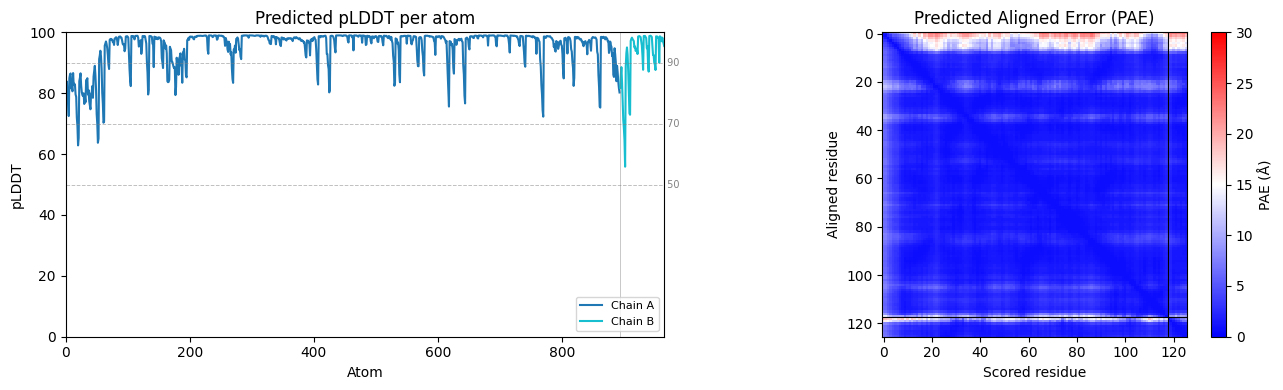

In [5]:
#@title Quality metrics and plots

def _quality_metrics():
    import json, os
    import numpy as np
    import matplotlib.pyplot as plt

    conf_path = f'{OUTPUT_DIR}/{jobname}/{jobname}_confidences.json'
    summ_path = f'{OUTPUT_DIR}/{jobname}/{jobname}_summary_confidences.json'

    with open(conf_path) as f:
      conf = json.load(f)
    with open(summ_path) as f:
      summ = json.load(f)

    plddts = np.array(conf.get('atom_plddts', conf.get('token_plddts', [])), dtype=float)
    plddt_chain_ids = conf.get('atom_chain_ids', conf.get('token_chain_ids', []))   # pLDDT is per-ATOM
    token_chain_ids = conf.get('token_chain_ids', [])                                # PAE is per-TOKEN
    pae = np.array(conf.get('pae', []), dtype=float)

    # ── Summary (ipTM is None for single-chain jobs — guard before formatting) ─
    def fmt(v):
      return f'{v:.3f}' if isinstance(v, (int, float)) else 'n/a'

    mean_plddt = summ.get('mean_plddt')
    if mean_plddt is None and plddts.size:
      mean_plddt = float(np.mean(plddts))
    iptm = summ.get('iptm')

    print('=' * 38)
    print(f'Mean pLDDT     : {fmt(mean_plddt)}')
    print(f'pTM            : {fmt(summ.get("ptm"))}')
    print(f'ipTM           : {fmt(iptm)}' + ('   (single chain — no interface)' if iptm is None else ''))
    print(f'Ranking score  : {fmt(summ.get("ranking_score"))}')
    print('=' * 38)

    # ── Plots ───────────────────────────────────────────────────
    has_pae = pae.ndim == 2 and pae.size > 0
    ncols = 2 if has_pae else 1
    fig, axes = plt.subplots(1, ncols, figsize=(13 if has_pae else 6.5, 4))
    axes = np.atleast_1d(axes)

    # pLDDT per residue — a line (coloured per chain when there is more than one)
    ax = axes[0]
    x = np.arange(len(plddts))
    xmax = max(len(plddts) - 1, 1)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, 100)

    unique_chains = list(dict.fromkeys(plddt_chain_ids))
    if len(unique_chains) > 1:
      colors = plt.cm.tab10(np.linspace(0, 1, len(unique_chains)))
      tcid = np.array(plddt_chain_ids)
      for ch, col in zip(unique_chains, colors):
        y = np.where(tcid == ch, plddts, np.nan)   # NaN gaps keep chains as separate lines
        ax.plot(x, y, lw=1.5, color=col, label=f'Chain {ch}')
      for b in [i for i in range(1, len(plddt_chain_ids)) if plddt_chain_ids[i] != plddt_chain_ids[i-1]]:
        ax.axvline(b - 0.5, color='grey', lw=0.6, alpha=0.5)
      ax.legend(loc='lower right', fontsize=8)
    else:
      ax.plot(x, plddts, lw=1.5, color='#1f77b4')

    for y in (50, 70, 90):
      ax.axhline(y, ls='--', lw=0.7, color='grey', alpha=0.5)
      ax.text(xmax, y, f' {y}', va='center', ha='left', fontsize=7, color='grey')
    ax.set_xlabel('Atom')
    ax.set_ylabel('pLDDT')
    ax.set_title('Predicted pLDDT per atom')

    # PAE matrix
    if has_pae:
      ax = axes[1]
      im = ax.imshow(pae, cmap='bwr', vmin=0, vmax=30, interpolation='nearest')
      plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='PAE (Å)')
      if token_chain_ids:
        for b in [i for i in range(1, len(token_chain_ids)) if token_chain_ids[i] != token_chain_ids[i-1]]:
          ax.axhline(b - 0.5, c='black', lw=0.8)
          ax.axvline(b - 0.5, c='black', lw=0.8)
      ax.set_xlabel('Scored residue')
      ax.set_ylabel('Aligned residue')
      ax.set_title('Predicted Aligned Error (PAE)')

    plt.tight_layout()
    plt.show()

try:
    _quality_metrics()
except Exception as _e:
    print(f'[quality-metrics skipped, non-fatal] {type(_e).__name__}: {_e}')


## 5HED ensemble effective-resistance analysis

This section uses the same definitions as `SECONDS.py` for each AF3 structure:

\[
R_{ij}=L^+_{ii}+L^+_{jj}-2L^+_{ij},\qquad
R_{i,\mathrm{cumulative}}=\sqrt{\frac{1}{N}\sum_j R_{ij}}.
\]

For the default 5HED job, chain **A** (118 residues, mapped to experimental residue numbers 298–415) is the protein and chain **B** (KNYKQFSV) is the bound peptide ligand. The ligand is eliminated by the same Schur/Kron reduction used in `SECONDS.py`.

The cell below:
1. finds up to 25 AF3 CIF models;
2. converts each CIF to PDB and calls `SECONDS.py` functions without changing their formulas;
3. computes the 25 residue profiles;
4. reports per-residue SD/CV, a mean +/- 1.96 SD ensemble band, model-wise NRMSE and correlation to the mean;
5. saves raw profiles and summary CSVs;
6. produces a diagnostic figure always, and a publication-style mean +/- 1.96 SD band figure only if the configurable stability criteria are passed.

**Ensemble size.** 25 models (5 seeds x 5 diffusion samples) is the default. At the AF3 model-to-model spread seen for this system the residue-wise CV is a few percent, so the standard error of the mean profile is already well below the ligand-induced signal. Empirical 2.5/97.5 quantiles are unreliable at n=25 and are reported for reference only; the plotted band is the Gaussian mean +/- 1.96 SD, which is stable at this sample size. Raise `max_models` and the seed list to 40+ if you specifically want an empirical quantile band.

**Important:** put `SECONDS.py` (or `SECONDS(2).py`) in the Colab working directory before running this cell. The experimental reference is **not searched by filename**: it is always the exact `5HED.pdb` selected in the notebook's first upload cell (`INPUT_PDB_PATH`).


Using SECONDS implementation: SECONDS.py
AF3 models selected for ensemble analysis: 25
Processed  10/25 models  |  valid=10  failed=0
Processed  20/25 models  |  valid=20  failed=0
Processed  25/25 models  |  valid=25  failed=0

ENSEMBLE DEVIATION SUMMARY
Valid AF3 structures                  : 25/25
Median residue CV                     :    0.519 %
95th percentile residue CV            :    1.606 %
Median |pointwise relative deviation| :    0.402 %
95th percentile |relative deviation|  :    1.624 %
Median model NRMSE vs ensemble mean   :    0.767 %
95th percentile model NRMSE           :    1.373 %
5th percentile curve correlation      :   0.9992
--------------------------------------------------------------------
Stability criteria:
  median CV <= 5%       : True
  p95 CV    <= 10%       : True
  p05 corr  >= 0.95      : True
OVERALL: STABLE / publication plot enabled
Experimental reference is the SAME uploaded input: /content/5HED.pdb
Experimental/input PDB SHA-256: 220e53ca1860cc7

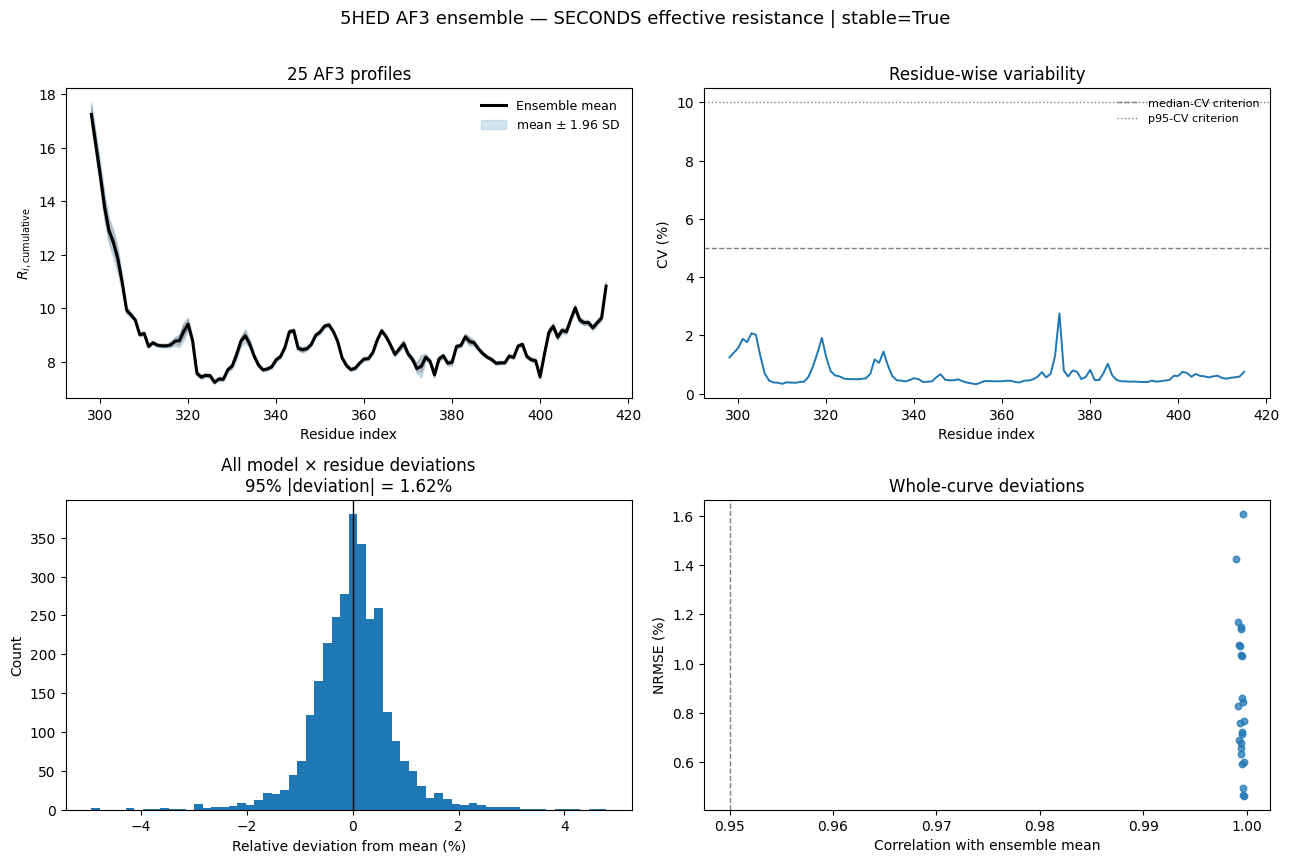

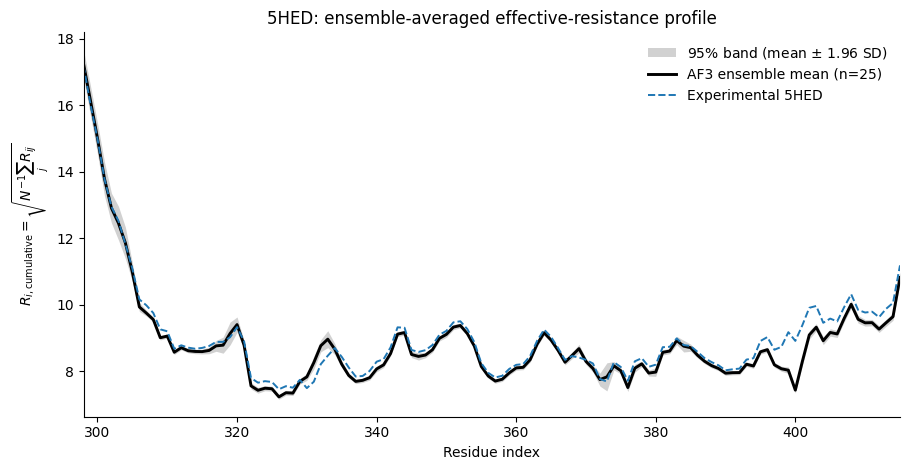

Publication figure saved: af3_output/5hed_25_20bdd/seconds_ensemble/5HED_AF3_mean_Rcumulative_95pct_band.png

Saved ensemble outputs:
  af3_output/5hed_25_20bdd/seconds_ensemble/5HED_AF3_ensemble_residue_stats.csv
  af3_output/5hed_25_20bdd/seconds_ensemble/5HED_AF3_ensemble_model_stats.csv
  af3_output/5hed_25_20bdd/seconds_ensemble/5HED_AF3_ensemble_all_profiles.csv
  af3_output/5hed_25_20bdd/seconds_ensemble/5HED_AF3_ensemble_stability_summary.txt
  af3_output/5hed_25_20bdd/seconds_ensemble/5HED_AF3_ensemble_diagnostics.png


In [8]:
#@title 5HED: 25-model SECONDS ensemble analysis
import os, glob, csv, json, importlib.util, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from Bio.PDB import MMCIFParser, PDBIO

# ---------------- User controls ----------------
max_models = 25 #@param {type:"integer"}
rc = 7.8 #@param {type:"number"}
d0 = 1.0 #@param {type:"number"}
residue_start = 298 #@param {type:"integer"}
expected_protein_residues = 118 #@param {type:"integer"}

# Heuristic stability criteria for deciding whether to emit the final publication plot.
# These are NOT universal physical laws; they are explicit reproducibility criteria and can be changed.
max_median_cv_percent = 5.0 #@param {type:"number"}
max_p95_cv_percent = 10.0 #@param {type:"number"}
min_p05_curve_correlation = 0.95 #@param {type:"number"}
force_publication_plot = False #@param {type:"boolean"}

max_models = max(2, int(max_models))

# ---------------- Load the user's SECONDS.py ----------------
def load_seconds_module():
    candidates = []
    for pat in ('SECONDS.py', 'SECONDS*.py', 'seconds.py', 'seconds*.py'):
        candidates.extend(glob.glob(pat))
    # Deduplicate while preserving order; do not accidentally load this notebook helper.
    candidates = list(dict.fromkeys(p for p in candidates if os.path.isfile(p)))
    if not candidates:
        raise FileNotFoundError(
            "SECONDS.py was not found in the Colab working directory. "
            "Upload SECONDS.py (or SECONDS(2).py), then rerun this cell."
        )
    path = candidates[0]
    spec = importlib.util.spec_from_file_location('seconds_user', path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    required = ['build_effective_laplacian', 'effective_distances',
                'compute_sqrt_mean_R_from_R']
    missing = [name for name in required if not hasattr(mod, name)]
    if missing:
        raise AttributeError(f'{path} is missing required functions: {missing}')
    print(f'Using SECONDS implementation: {path}')
    return mod, path

seconds, seconds_path = load_seconds_module()

# ---------------- Collect ALL seed x sample models in ranking order ----------------
def collect_model_records(job_dir, jobname):
    records = []
    ranking_csv = f'{job_dir}/{jobname}_ranking_scores.csv'
    if os.path.exists(ranking_csv):
        with open(ranking_csv) as f:
            rows = list(csv.DictReader(f))
        rows.sort(key=lambda r: float(r.get('ranking_score', '-inf')), reverse=True)
        for rank, r in enumerate(rows, start=1):
            seed = int(r['seed']); sample = int(r['sample'])
            d = f'{job_dir}/seed-{seed}_sample-{sample}'
            hits = sorted(glob.glob(f'{d}/*_model.cif')) or sorted(glob.glob(f'{d}/*.cif'))
            if hits:
                records.append({
                    'rank': rank, 'seed': seed, 'sample': sample,
                    'ranking_score': float(r.get('ranking_score', 'nan')),
                    'cif': hits[0]
                })
    if not records:
        hits = (sorted(glob.glob(f'{job_dir}/**/*_model.cif', recursive=True))
                or sorted(glob.glob(f'{job_dir}/**/*.cif', recursive=True)))
        for rank, cif in enumerate(hits, start=1):
            records.append({'rank': rank, 'seed': np.nan, 'sample': np.nan,
                            'ranking_score': np.nan, 'cif': cif})
    return records

records = collect_model_records(job_dir, jobname)
if not records:
    raise FileNotFoundError(f'No AF3 model CIFs found under {job_dir}/. Run the AF3 inference cell successfully first.')
if len(records) < max_models:
    warnings.warn(f'Only {len(records)} AF3 models were found; requested {max_models}. Using all available models.')
records = records[:max_models]
print(f'AF3 models selected for ensemble analysis: {len(records)}')

# ---------------- CIF -> PDB ----------------
# SECONDS.py is PDB-based; this conversion preserves AF3 coordinates and chain IDs.
conv_dir = Path(job_dir) / 'seconds_ensemble' / 'pdb_models'
conv_dir.mkdir(parents=True, exist_ok=True)
parser = MMCIFParser(QUIET=True)

def cif_to_pdb(cif_path, pdb_path):
    structure = parser.get_structure('af3', cif_path)
    io = PDBIO()
    io.set_structure(structure)
    io.save(str(pdb_path))

# ---------------- Compute one SECONDS profile per AF3 structure ----------------
profiles = []
valid_records = []
failures = []
for k, rec in enumerate(records, start=1):
    pdb_path = conv_dir / f"rank_{rec['rank']:03d}_seed_{rec['seed']}_sample_{rec['sample']}.pdb"
    try:
        if not pdb_path.exists():
            cif_to_pdb(rec['cif'], pdb_path)
        L, ids = seconds.build_effective_laplacian(
            str(pdb_path),
            protein_chains=('A',), ligand_chains=('B',),
            rc=rc, d0=d0, verbose=False
        )
        if len(ids) != expected_protein_residues:
            raise ValueError(f'expected {expected_protein_residues} chain-A residues, got {len(ids)}')
        R = seconds.effective_distances(L)
        profile = seconds.compute_sqrt_mean_R_from_R(R, np.arange(len(ids), dtype=int))
        if not np.all(np.isfinite(profile)):
            raise ValueError('non-finite profile values')
        profiles.append(profile)
        valid_records.append(rec)
    except Exception as e:
        failures.append((rec, str(e)))
    if k % 10 == 0 or k == len(records):
        print(f'Processed {k:3d}/{len(records)} models  |  valid={len(profiles)}  failed={len(failures)}')

if len(profiles) < 2:
    raise RuntimeError(f'Only {len(profiles)} valid profiles were obtained. Failures: {failures[:5]}')

P = np.vstack(profiles)  # shape: n_models x 118
n_models, n_res = P.shape
residue_index = residue_start + np.arange(n_res)

# ---------------- Ensemble statistics ----------------
mu = P.mean(axis=0)
sd = P.std(axis=0, ddof=1)
q025, q975 = np.quantile(P, [0.025, 0.975], axis=0)   # empirical; unreliable below ~40 models
# Gaussian 95% band. Stable at n = 25, unlike the empirical quantiles above.
band_lo = mu - 1.96 * sd
band_hi = mu + 1.96 * sd
cv_percent = 100.0 * sd / np.maximum(np.abs(mu), 1e-12)

rel_dev_percent = 100.0 * (P - mu[None, :]) / np.maximum(np.abs(mu[None, :]), 1e-12)
abs_rel_dev_percent = np.abs(rel_dev_percent)

rmse = np.sqrt(np.mean((P - mu[None, :])**2, axis=1))
nrmse_percent = 100.0 * rmse / max(float(np.mean(np.abs(mu))), 1e-12)
curve_corr = np.array([
    np.corrcoef(row, mu)[0, 1] if np.std(row) > 0 and np.std(mu) > 0 else np.nan
    for row in P
])

median_cv = float(np.median(cv_percent))
p95_cv = float(np.percentile(cv_percent, 95))
p05_corr = float(np.nanpercentile(curve_corr, 5))
median_abs_rel_dev = float(np.median(abs_rel_dev_percent))
p95_abs_rel_dev = float(np.percentile(abs_rel_dev_percent, 95))
median_nrmse = float(np.median(nrmse_percent))
p95_nrmse = float(np.percentile(nrmse_percent, 95))

stable = (median_cv <= max_median_cv_percent and
          p95_cv <= max_p95_cv_percent and
          p05_corr >= min_p05_curve_correlation)

print('\n' + '='*68)
print('ENSEMBLE DEVIATION SUMMARY')
print('='*68)
print(f'Valid AF3 structures                  : {n_models}/{len(records)}')
print(f'Median residue CV                     : {median_cv:8.3f} %')
print(f'95th percentile residue CV            : {p95_cv:8.3f} %')
print(f'Median |pointwise relative deviation| : {median_abs_rel_dev:8.3f} %')
print(f'95th percentile |relative deviation|  : {p95_abs_rel_dev:8.3f} %')
print(f'Median model NRMSE vs ensemble mean   : {median_nrmse:8.3f} %')
print(f'95th percentile model NRMSE           : {p95_nrmse:8.3f} %')
print(f'5th percentile curve correlation      : {p05_corr:8.4f}')
print('-'*68)
print('Stability criteria:')
print(f'  median CV <= {max_median_cv_percent:g}%       : {median_cv <= max_median_cv_percent}')
print(f'  p95 CV    <= {max_p95_cv_percent:g}%       : {p95_cv <= max_p95_cv_percent}')
print(f'  p05 corr  >= {min_p05_curve_correlation:g}      : {p05_corr >= min_p05_curve_correlation}')
print(f'OVERALL: {"STABLE / publication plot enabled" if stable else "NOT STABLE by these thresholds"}')
if failures:
    print(f'WARNING: {len(failures)} model(s) failed. First failures:')
    for rec, msg in failures[:5]:
        print(f"  rank {rec['rank']}: {msg}")

# ---------------- Experimental 5HED reference: EXACT SAME uploaded file ----------------
ref_profile = None
if 'INPUT_PDB_PATH' not in globals() or not os.path.isfile(INPUT_PDB_PATH):
    raise RuntimeError('Uploaded 5HED.pdb is no longer available. Rerun the FIRST upload cell.')
ref_pdb = INPUT_PDB_PATH
try:
    Lref, idsref = seconds.build_effective_laplacian(
        ref_pdb, protein_chains=('A',), ligand_chains=('B',), rc=rc, d0=d0, verbose=False)
    Rref = seconds.effective_distances(Lref)
    ref_profile = seconds.compute_sqrt_mean_R_from_R(Rref, np.arange(len(idsref), dtype=int))
    if len(ref_profile) != n_res:
        warnings.warn(f'Experimental reference has {len(ref_profile)} residues, expected {n_res}; overlay skipped.')
        ref_profile = None
    else:
        print(f'Experimental reference is the SAME uploaded input: {ref_pdb}')
        if 'PDB_SHA256' in globals():
            print(f'Experimental/input PDB SHA-256: {PDB_SHA256}')
except Exception as e:
    warnings.warn(f'Could not compute experimental 5HED reference profile from the uploaded input: {e}')
    ref_profile = None

# ---------------- Save numeric outputs ----------------
out_dir = Path(job_dir) / 'seconds_ensemble'
out_dir.mkdir(parents=True, exist_ok=True)

summary_csv = out_dir / '5HED_AF3_ensemble_residue_stats.csv'
with open(summary_csv, 'w', newline='') as f:
    w = csv.writer(f)
    header = ['Residue_Index', 'Mean_Rcum', 'SD_Rcum',
              'Band_Lo_Mean_minus_1.96SD', 'Band_Hi_Mean_plus_1.96SD',
              'Q2.5_Rcum_empirical', 'Q97.5_Rcum_empirical', 'CV_percent']
    if ref_profile is not None:
        header.append('Experimental_5HED_Rcum')
    w.writerow(header)
    for i, res in enumerate(residue_index):
        row = [int(res), mu[i], sd[i], band_lo[i], band_hi[i],
               q025[i], q975[i], cv_percent[i]]
        if ref_profile is not None:
            row.append(ref_profile[i])
        w.writerow(row)

model_csv = out_dir / '5HED_AF3_ensemble_model_stats.csv'
with open(model_csv, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Rank', 'Seed', 'Sample', 'Ranking_Score', 'RMSE', 'NRMSE_percent', 'Correlation_to_Mean'])
    for rec, a, b, c in zip(valid_records, rmse, nrmse_percent, curve_corr):
        w.writerow([rec['rank'], rec['seed'], rec['sample'], rec['ranking_score'], a, b, c])

profiles_csv = out_dir / '5HED_AF3_ensemble_all_profiles.csv'
with open(profiles_csv, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Model'] + [int(x) for x in residue_index])
    for rec, row in zip(valid_records, P):
        w.writerow([f"rank_{rec['rank']}_seed_{rec['seed']}_sample_{rec['sample']}"] + list(row))

stats_txt = out_dir / '5HED_AF3_ensemble_stability_summary.txt'
with open(stats_txt, 'w') as f:
    f.write(f'n_valid = {n_models}\n')
    f.write(f'n_requested = {len(records)}\n')
    f.write(f'median_residue_CV_percent = {median_cv:.6f}\n')
    f.write(f'p95_residue_CV_percent = {p95_cv:.6f}\n')
    f.write(f'median_abs_relative_deviation_percent = {median_abs_rel_dev:.6f}\n')
    f.write(f'p95_abs_relative_deviation_percent = {p95_abs_rel_dev:.6f}\n')
    f.write(f'median_model_NRMSE_percent = {median_nrmse:.6f}\n')
    f.write(f'p95_model_NRMSE_percent = {p95_nrmse:.6f}\n')
    f.write(f'p05_curve_correlation = {p05_corr:.8f}\n')
    f.write(f'stable_by_configured_criteria = {stable}\n')
    f.write('band_definition = mean +/- 1.96 SD (Gaussian; stable at n=25)\n')
    f.write(f'criteria_median_CV_percent_max = {max_median_cv_percent}\n')
    f.write(f'criteria_p95_CV_percent_max = {max_p95_cv_percent}\n')
    f.write(f'criteria_p05_curve_correlation_min = {min_p05_curve_correlation}\n')

# ---------------- Diagnostic figure: always produced ----------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

ax = axes[0, 0]
for row in P:
    ax.plot(residue_index, row, lw=0.7, alpha=0.13, color='0.35')
ax.plot(residue_index, mu, lw=2.2, color='black', label='Ensemble mean')
ax.fill_between(residue_index, band_lo, band_hi, alpha=0.18, color='tab:blue',
                label='mean $\\pm$ 1.96 SD')
ax.set_xlabel('Residue index')
ax.set_ylabel(r'$R_{i,\mathrm{cumulative}}$')
ax.set_title(f'{n_models} AF3 profiles')
ax.legend(frameon=False, fontsize=9)

ax = axes[0, 1]
ax.plot(residue_index, cv_percent, lw=1.4)
ax.axhline(max_median_cv_percent, ls='--', lw=1, color='0.5', label='median-CV criterion')
ax.axhline(max_p95_cv_percent, ls=':', lw=1, color='0.5', label='p95-CV criterion')
ax.set_xlabel('Residue index')
ax.set_ylabel('CV (%)')
ax.set_title('Residue-wise variability')
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
ax.hist(rel_dev_percent.ravel(), bins=60, edgecolor='none')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Relative deviation from mean (%)')
ax.set_ylabel('Count')
ax.set_title(f'All model × residue deviations\n95% |deviation| = {p95_abs_rel_dev:.2f}%')

ax = axes[1, 1]
ax.scatter(curve_corr, nrmse_percent, s=22, alpha=0.75)
ax.axvline(min_p05_curve_correlation, ls='--', lw=1, color='0.5')
ax.set_xlabel('Correlation with ensemble mean')
ax.set_ylabel('NRMSE (%)')
ax.set_title('Whole-curve deviations')

fig.suptitle(f'5HED AF3 ensemble — SECONDS effective resistance | stable={stable}', y=1.01, fontsize=13)
plt.tight_layout()
diagnostic_png = out_dir / '5HED_AF3_ensemble_diagnostics.png'
fig.savefig(diagnostic_png, dpi=300, bbox_inches='tight')
plt.show()

# ---------------- Publication-style figure ----------------
if stable or force_publication_plot:
    fig, ax = plt.subplots(figsize=(9.2, 4.8))
    ax.fill_between(residue_index, band_lo, band_hi, color='0.82', linewidth=0,
                    label='95% band (mean $\\pm$ 1.96 SD)')
    ax.plot(residue_index, mu, color='black', lw=2.1, label=f'AF3 ensemble mean (n={n_models})')
    if ref_profile is not None:
        ax.plot(residue_index, ref_profile, lw=1.4, ls='--', label='Experimental 5HED')
    ax.set_xlabel('Residue index')
    ax.set_ylabel(r'$R_{i,\mathrm{cumulative}}=\sqrt{N^{-1}\sum_j R_{ij}}$')
    ax.set_xlim(residue_index[0], residue_index[-1])
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('5HED: ensemble-averaged effective-resistance profile')
    plt.tight_layout()
    pub_png = out_dir / '5HED_AF3_mean_Rcumulative_95pct_band.png'
    pub_pdf = out_dir / '5HED_AF3_mean_Rcumulative_95pct_band.pdf'
    fig.savefig(pub_png, dpi=600, bbox_inches='tight')
    fig.savefig(pub_pdf, bbox_inches='tight')
    plt.show()
    print(f'Publication figure saved: {pub_png}')
else:
    print('\nPublication plot was NOT emitted because the configured stability criteria were not all met.')
    print('Inspect the diagnostic figure/statistics first. Set force_publication_plot=True only if scientifically justified.')

print('\nSaved ensemble outputs:')
for p in [summary_csv, model_csv, profiles_csv, stats_txt, diagnostic_png]:
    print(' ', p)


In [9]:
#@title Download results (including SECONDS ensemble outputs)
from google.colab import files
import os

results_zip = f'{jobname}.result.zip'
os.system(f'zip -r {results_zip} {OUTPUT_DIR}/{jobname}')
files.download(results_zip)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Instructions <a name="Instructions"></a>

**Quick start**
1. Press **Runtime → Run all**.
2. The first executable cell asks for exactly **`5HED.pdb`**. Select your file there.
3. The notebook extracts chain A and chain B sequences directly from that uploaded PDB and prints its SHA-256 fingerprint for verification.
4. The install/inference cells then run normally; the same uploaded PDB is also used later as the experimental SECONDS reference.

---

## Model weights

By default the notebook uses the open **OpenFold3** weights (Apache-2.0, no restrictions). To run the **official AlphaFold 3** weights instead, tick the **use_af3_weights** box in the install cell. The weights are now publicly downloadable (no login, key, or DeepMind approval required) and are fetched directly into `af3_native_weights/`, then used automatically (the run cell detects them and drops the `--of3_weights` flag). Leaving **use_af3_weights** off keeps the OpenFold3 path.

Official AlphaFold 3 parameters are subject to the [AF3 weights terms of use](https://github.com/google-deepmind/alphafold3/blob/main/WEIGHTS_TERMS_OF_USE.md); run_alphafold prints a reminder of these terms when they are used.

---

## Sequence input

Each molecule type has its own box. Within a box, separate multiple chains with `:`.

| Box | What goes in it | Example |
|---|---|---|
| **protein** | amino-acid sequence(s) | `MKTAY...` or `SEQ1:SEQ2` |
| **dna** | DNA sequence(s) | `CGCGAATTCGCG` |
| **rna** | RNA sequence(s) | `GCGGAUUUA` |
| **ligand_ccd** | ligand(s) by PDB CCD code | `ATP:MG:HEM` |
| **ligand_smiles** | ligand(s) by SMILES | `CC(=O)Oc1ccccc1C(=O)O` |

Chains are assigned IDs A, B, C, … following AlphaFold 3's canonical order (protein → RNA → DNA → ligand; CCD ligands before SMILES ligands). Mix freely across boxes to build a complex — e.g. a protein in **protein**, `AUGCAUGC` in **rna**, and `ATP` in **ligand_ccd**.

- **Homo-oligomers**: identical protein sequences are merged automatically, so `SEQ:SEQ` = homodimer, `SEQ:SEQ:SEQ` = homotrimer.
- Protein / DNA / RNA sequences and CCD codes are upper-cased automatically; **SMILES are left exactly as typed** (case is meaningful in SMILES).
- Spaces and newlines inside an entry are ignored, and **extra colons are forgiven** — `SEQ1::::SEQ2` is the same as `SEQ1:SEQ2`. Leave a box empty if unused.
- *Note:* because `:` separates entries, an atom-mapped SMILES that itself contains a colon (e.g. `[C:1]`) isn't supported via the box — use a raw AF3 JSON for that edge case.

## Seeds

Enter one or more model seeds in the **seeds** box, comma-separated (e.g. `1,2,3`). Each seed is an independent prediction (more seeds = more sampling, more runtime). Non-numeric characters are ignored and duplicates are dropped, so `1, 1, foo, 7` becomes seeds `1` and `7`.

## MSA modes

- **`mmseqs2_server`** *(recommended)*: queries the public [ColabFold](https://colabfold.mmseqs.com/) MMseqs2 API. Covers UniRef30 + environmental sequences for proteins. RNA/DNA chains always run MSA-free (ColabFold is protein-only).
- **`single_sequence`**: no MSA, query sequence only. Faster but less accurate, especially for monomers with close homologs.

## Output files (inside the downloaded zip)

| File | Contents |
|---|---|
| `*.cif` | Best-ranked structure in mmCIF format. B-factor = pLDDT (0–100). |
| `*_confidences.json` | Per-residue pLDDT, PAE matrix, contact probs. |
| `*_summary_confidences.json` | Mean pLDDT, pTM, ipTM, ranking score. |
| `*_ranking_scores.csv` | Ranking scores for all seed × sample combinations. |
| `seed-N_sample-M/` | Individual prediction directories (one per seed/sample). |
| `TERMS_OF_USE.md` | Apache 2.0 notice (OpenFold3 weights have no commercial restrictions). |

## Interpreting confidence scores

- **pLDDT > 90**: very high confidence.
- **pLDDT 70–90**: confident, backbone generally reliable.
- **pLDDT 50–70**: low confidence, treat with caution.
- **pLDDT < 50**: very low, likely disordered or incorrect.
- **PAE**: lower values = confident relative positioning between residue pairs. Useful for assessing interface quality in complexes.
- **ipTM > 0.8**: strong evidence for a well-defined complex interface. **ipTM is `n/a` for single-chain jobs** (there is no interface to score).

## Troubleshooting

- **Check runtime type**: `Runtime → Change runtime type → GPU` (T4 is fine; A100/L4 are faster).
- **OOM error**: reduce sequence length or use a larger-memory GPU runtime.
- **MSA server timeout**: the public ColabFold server is rate-limited. Try again later or switch to `single_sequence` mode.
- **Download popup blocked**: disable your ad blocker.
- **Weight download slow**: the OF3 checkpoint is ~1.4 GB from AWS S3; the install cell waits automatically.

## License

AlphaFold 3 source code and OpenFold3 weights are both licensed under [Apache 2.0](https://www.apache.org/licenses/LICENSE-2.0). Outputs generated with OpenFold3 weights are **not** subject to Google DeepMind's AlphaFold 3 Output Terms of Use and may be used freely, including commercially.

## Bugs / feedback

Report issues at https://github.com/sokrypton/alphafold3/issues
